# Alpha Sweep Analysis (eps=0.1, budget=1000)

This notebook analyzes the results of the alpha sweep experiment where synthetic data was generated with `eps=0.1` and marginals were obtained with a high privacy budget (`1000`) to simulate near-perfect marginal information.

In [19]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_theme(style="whitegrid")

## 1. Load Data

We iterate through the result directories and collect metrics into a single DataFrame.

In [20]:
# Load aggregated data
df = pd.read_csv('../experiments_alpha_eps01_b1000.csv')

# Pre-processing
df['engine'] = df['meta_synthesizer_params_model_path'].apply(lambda x: 'aim' if 'aim' in str(x).lower() else ('mst' if 'mst' in str(x).lower() else 'patectgan'))
df['alpha'] = df['meta_repairer_params_alpha']

# Map columns to names used in the notebook
column_mapping = {
    'deletion_ratio_ratio': 'deletion_ratio',
    'marginals_error_synthetic_avg': 'marginal_error_syn',
    'marginals_error_repaired_avg': 'marginal_error_rep',
    'tvd_2way_synthetic_avg': 'tvd_syn',
    'tvd_2way_repaired_avg': 'tvd_rep',
    'violations_synthetic': 'violations_syn',
    'violations_repaired': 'violations_rep',
    'runtime_repairing': 'runtime_repairing',
    'marginal_generation_quality_avg_relative_error': 'marginal_gen_error',
    'marginal_selection_quality_precision_at_k': 'marginal_sel_precision',
    'marginal_selection_quality_overlap_count': 'marginal_sel_overlap'
}

for old_col, new_col in column_mapping.items():
    if old_col in df.columns:
        df[new_col] = df[old_col]

# Map ML columns
for col in df.columns:
    if col.startswith('ml_accuracy_synthetic_'):
        df[col.replace('ml_accuracy_synthetic_', 'ml_') + '_syn'] = df[col]
    elif col.startswith('ml_accuracy_repaired_'):
        df[col.replace('ml_accuracy_repaired_', 'ml_') + '_rep'] = df[col]

print(f"Successfully loaded {len(df)} unique experiments.")
df.head()

Successfully loaded 140 unique experiments.


,dataset,experiment_name,experiment_id,timestamp,meta_loader,meta_synthesizer,meta_obtainer,meta_repairer,meta_synthesizer_params_model_path,meta_synthesizer_params_size,...,violations_rep,marginal_gen_error,marginal_sel_precision,marginal_sel_overlap,ml_logistic_regression_syn,ml_random_forest_syn,ml_mlp_syn,ml_logistic_regression_rep,ml_random_forest_rep,ml_mlp_rep
0,adult,alpha_eps01_b1000_adult_aim_a0.75,0b5795ec,2026-05-17T07:49:56.560706,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.809959,0.817903,0.822407
1,adult,alpha_eps01_b1000_adult_aim_a0.8,ad20a3f7,2026-05-17T04:15:16.669826,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810163,0.817985,0.819049
2,adult,alpha_eps01_b1000_adult_aim_a0.85,48f78298,2026-05-17T05:49:14.787513,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810143,0.817882,0.818640
3,adult,alpha_eps01_b1000_adult_aim_a0.9,335b39df,2026-05-17T07:22:30.199510,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810122,0.817288,0.818025
4,adult,alpha_eps01_b1000_adult_aim_a0.95,7bd01308,2026-05-17T08:34:18.468099,FileLoader,SmartNoiseModelLoader,TopKObtainer,WeightedVCRepairer,models/adult_aim_eps0.1.pkl,50000,...,0,0.000103,1.0,20.0,0.806539,0.81864,0.816736,0.810143,0.818578,0.812579


## 2. Impact of Alpha on Data Utility

We analyze how the repair parameter `alpha` affects the tradeoff between data size (deletion ratio) and statistical utility (marginal error and TVD).

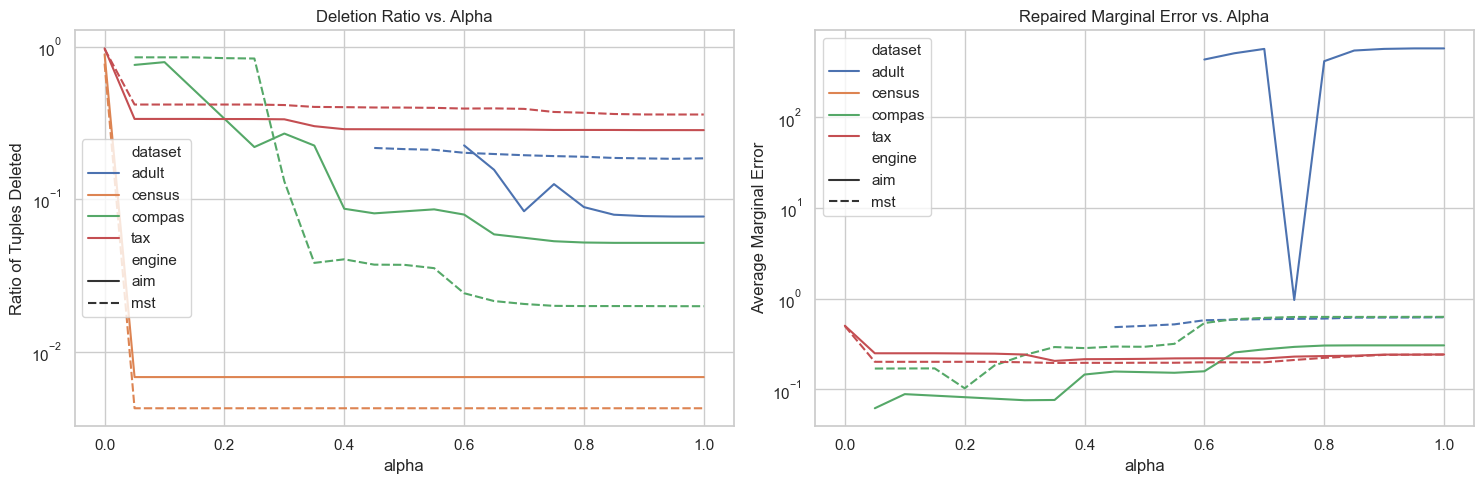

In [21]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.lineplot(data=df, x="alpha", y="deletion_ratio", hue="dataset", style="engine", ax=axes[0])
    axes[0].set_title("Deletion Ratio vs. Alpha")
    axes[0].set_ylabel("Ratio of Tuples Deleted")
    axes[0].set_yscale('log')
    
    sns.lineplot(data=df, x="alpha", y="marginal_error_rep", hue="dataset", style="engine", ax=axes[1])
    axes[1].set_title("Repaired Marginal Error vs. Alpha")
    axes[1].set_ylabel("Average Marginal Error")
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot utility.")

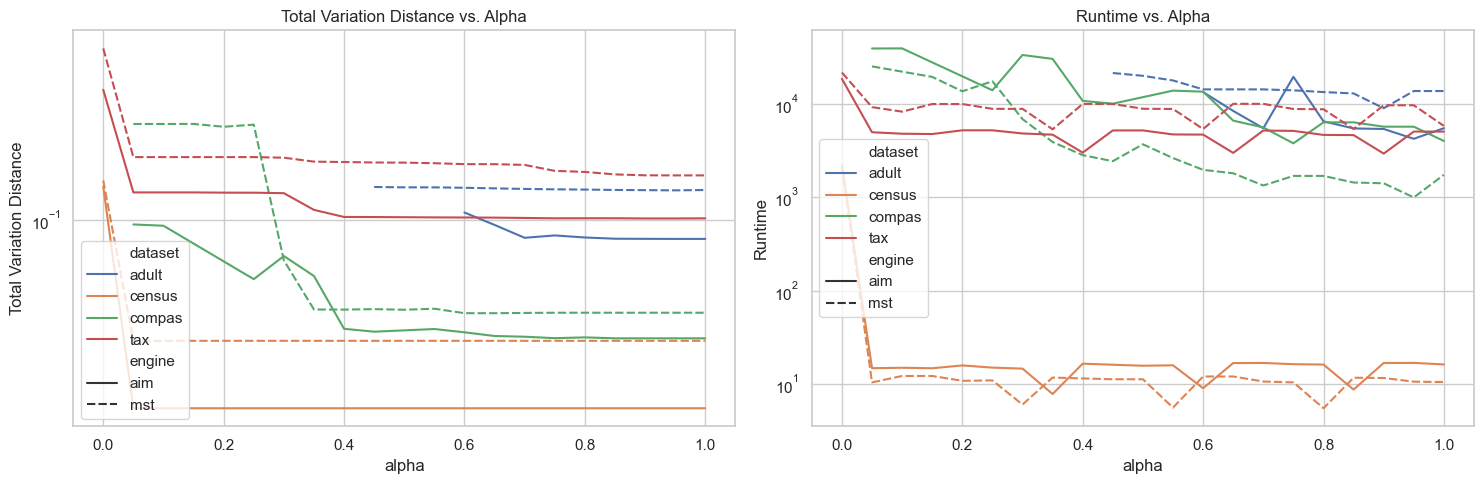

In [22]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    sns.lineplot(data=df, x="alpha", y="tvd_rep", hue="dataset", style="engine", ax=axes[0])
    axes[0].set_title("Total Variation Distance vs. Alpha")
    axes[0].set_ylabel("Total Variation Distance")
    axes[0].set_yscale('log')
    
    sns.lineplot(data=df, x="alpha", y="runtime_repairing", hue="dataset", style="engine", ax=axes[1])
    axes[1].set_title("Runtime vs. Alpha")
    axes[1].set_ylabel("Runtime")
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot utility.")

## 3. Statistical Utility Improvement

Comparing synthetic data utility vs. repaired data utility across different alpha values.

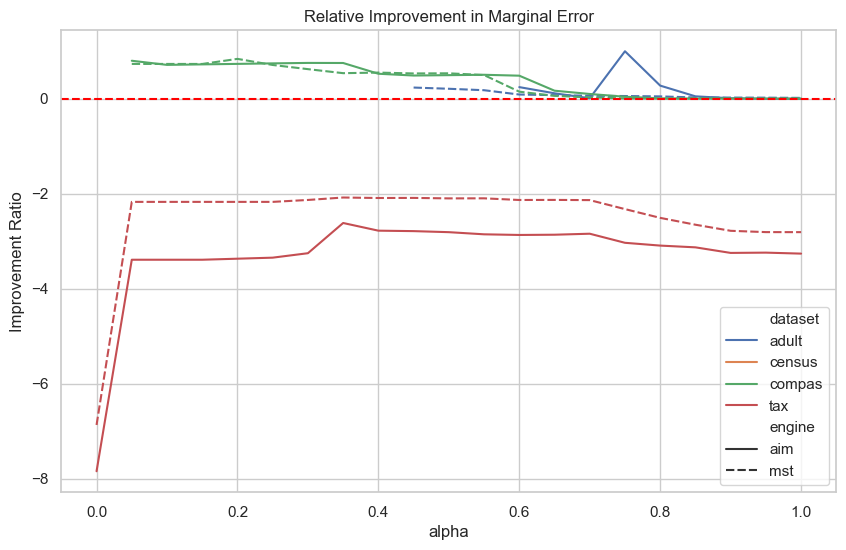

In [23]:
if not df.empty:
    # Avoid division by zero
    df['marginal_improvement'] = np.where(
        df['marginal_error_syn'] != 0, 
        (df['marginal_error_syn'] - df['marginal_error_rep']) / df['marginal_error_syn'],
        0
    )

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="alpha", y="marginal_improvement", hue="dataset", style="engine")
    plt.title("Relative Improvement in Marginal Error")
    plt.ylabel("Improvement Ratio")
    plt.axhline(0, color='red', linestyle='--')
    plt.show()
else:
    print("No data available to plot improvement.")

In [30]:
df[df['dataset'] == 'compas'][["marginal_error_syn", "engine", "dataset", "alpha"]]

,marginal_error_syn,engine,dataset,alpha
59,0.305817,aim,compas,0.05
60,0.305817,aim,compas,0.10
61,0.305817,aim,compas,0.30
62,0.305817,aim,compas,0.35
63,0.305817,aim,compas,0.40
64,0.305817,aim,compas,0.45
65,0.305817,aim,compas,0.55
66,0.305817,aim,compas,0.60
67,0.305817,aim,compas,0.65
68,0.305817,aim,compas,0.70


## 4. Marginals Generation Process Quality

We evaluate the quality of the marginal selection and generation steps. Since the budget is high (1000), we expect very high precision and low error.

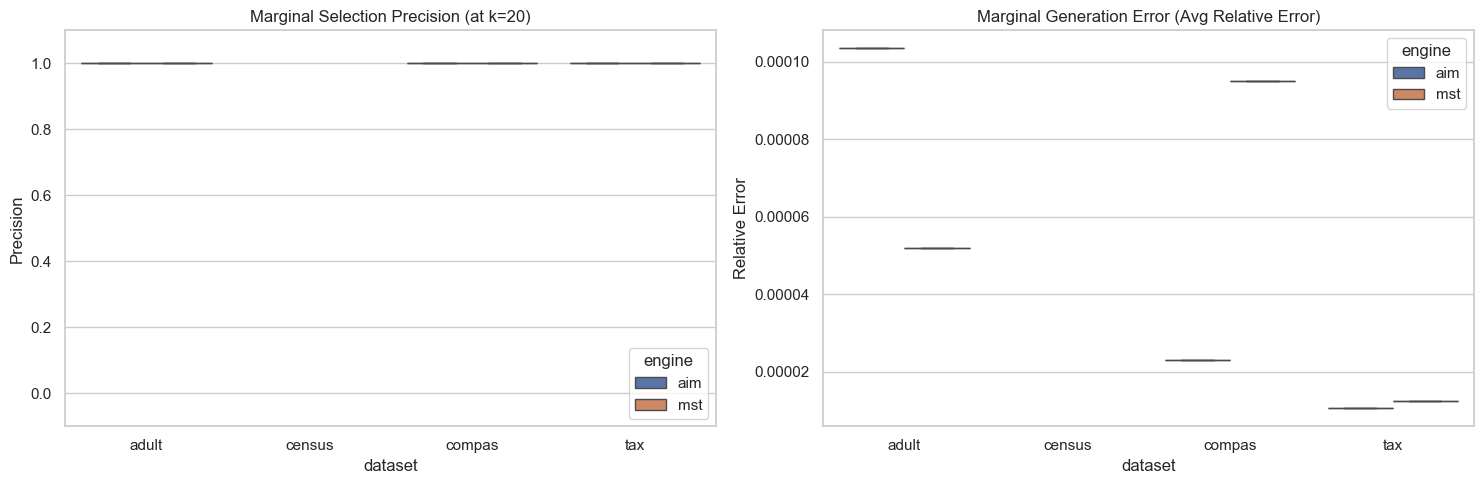

In [25]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Marginal Selection Precision
    sns.boxplot(data=df, x="dataset", y="marginal_sel_precision", hue="engine", ax=axes[0])
    axes[0].set_title("Marginal Selection Precision (at k=20)")
    axes[0].set_ylabel("Precision")
    axes[0].set_ylim(-0.1, 1.1)


    # Marginal Generation Error
    sns.boxplot(data=df, x="dataset", y="marginal_gen_error", hue="engine", ax=axes[1])
    axes[1].set_title("Marginal Generation Error (Avg Relative Error)")
    axes[1].set_ylabel("Relative Error")
    # axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot marginal quality.")

## 5. Constraint Satisfaction

Verifying that the repair process successfully reduces the number of DC violations.

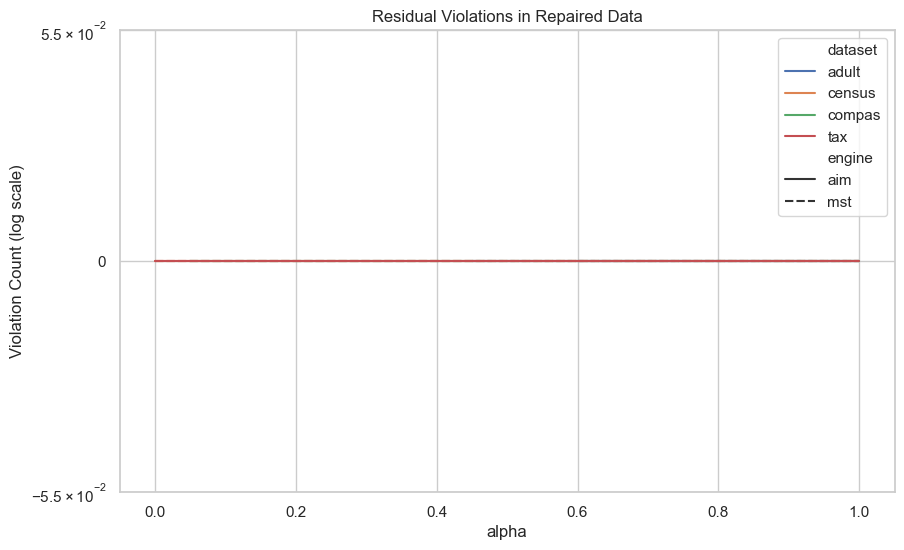

In [26]:
if not df.empty:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="alpha", y="violations_rep", hue="dataset", style="engine")
    plt.title("Residual Violations in Repaired Data")
    plt.yscale('symlog')
    plt.ylabel("Violation Count (log scale)")
    plt.show()
else:
    print("No data available to plot violations.")

## 6. Machine Learning Accuracy

Comparing downstream task performance on synthetic vs. repaired data.

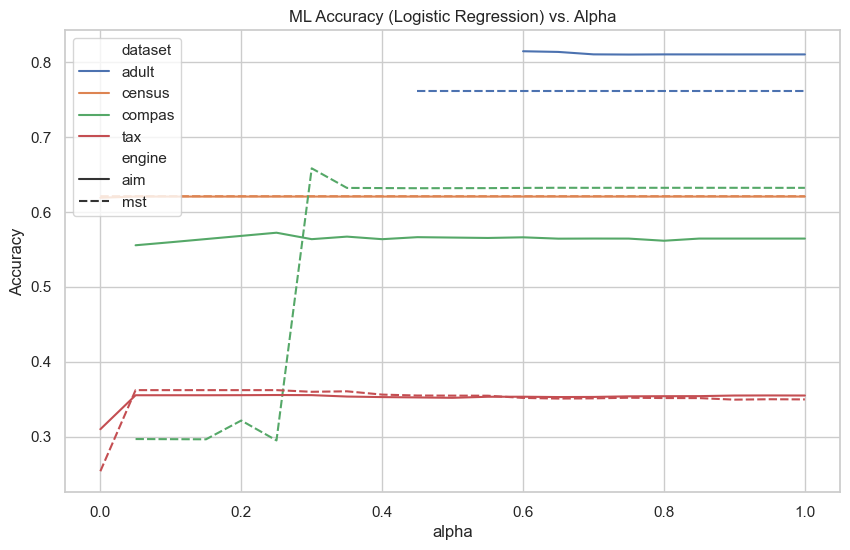

In [27]:
if not df.empty:
    ml_models = [c for c in df.columns if c.startswith("ml_") and c.endswith("_rep")]
    if ml_models:
        model_to_plot = ml_models[0]
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=df, x="alpha", y=model_to_plot, hue="dataset", style="engine")
        plt.title(f"ML Accuracy ({model_to_plot.replace('_rep', '').replace('ml_', '').replace('_', ' ').title()}) vs. Alpha")
        plt.ylabel("Accuracy")
        plt.show()
    else:
        print("No ML accuracy data found.")
else:
    print("No data available to plot accuracy.")

## Conclusion

- Summary of findings regarding the optimal alpha range for the high-budget marginal regime.
- Comparison between AIM and MST engines under this regime.